#### XGBoostClassifier

It is an advanced version of ensemble machine learning technique that works on the principle of boosting.

It is more better than Gradient Boosting technique  as

(i)     It improves speed.

(ii)    It improves  accuracy.

(iii)   It provides  stability.

(iv)    It improves the regularization of the model.


####  Step  1:  Import  all   the   necessary  libraries

In [ ]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection import  train_test_split,   GridSearchCV,   StratifiedKFold
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    xgboost                 import  XGBClassifier
from    sklearn.metrics         import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

#### Step 2:    Load the dataset

In [1042]:
df = pd.read_csv("Social_Network_Ads.csv")

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


#### OBSERVATIONS:

1.  The above dataset explains whether the particular customer has purchased the product or not based on it's details.

2.  The independent features in the dataset is:----

      (a.)  Gender ------------>   Gender of the customer

      (b.)  Age    ------------>   Age    of the customer

      (c.)  EstimatedSalary ----->  Salary o the customer


3.  The dependent feature in the dataset is

     (a.)  Purchased ------------->  It explains whether the customer has purchased the product or not.

#### Step 3:    Perform the Data Exploration

In [1043]:
#### get the top five rows of the dataset

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [1044]:
#### get the bottom five rows of the dataset

df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [1045]:
#### length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 400


In [1046]:
#### Shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (400, 5)


In [1047]:
#### get the columns used in the dataset

df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [1048]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [1049]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [1050]:
#### get the correlation between all the columns in the dataset

dfa = df[['User ID',	'Age',	'EstimatedSalary',	'Purchased']]

dfa.corr()

,User ID,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.000721,0.071097,0.007120
Age,-0.000721,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,0.155238,1.000000,0.362083
Purchased,0.007120,0.622454,0.362083,1.000000


<Axes: >

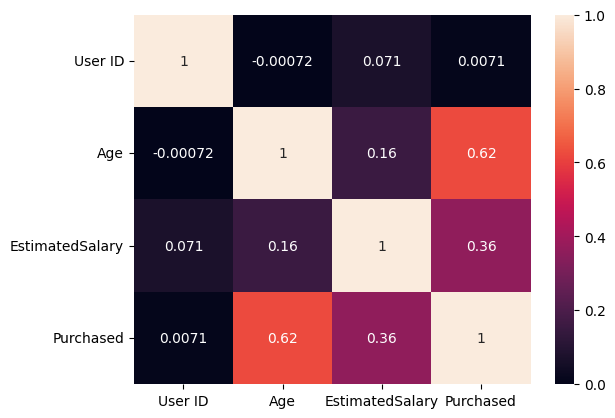

In [1051]:
#### Get the graphical representation between all the numerical columns in the dataset

sns.heatmap(dfa.corr(), annot=True)

#### Step 4:  Perform the Data Cleaning and Feature Engineering

In [1052]:
#### To check for the NULL records in the dataset

df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1053]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,User ID,Gender,Age,EstimatedSalary,Purchased


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [1054]:
#### Remove the unnecessary columns from the dataset

df.drop(columns = ['User ID','Gender'],axis=1,inplace=True)

In [1055]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


#### OBSERVATIONS:

1.  We have the revised dataset that contains the columns 'Age', 'EstimatedSalary' and 'Purchased'.

2.  The inputs in the dataset are 'Age' and the 'EstimatedSalary' and the output is 'Purchased'.

3.  Based on the age and the estimatedsalary of the person, we can now predict whether the customer has purchased the product or not.

In [1056]:
#### Length of the revised dataset 

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 400


In [1057]:
#### Shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (400, 3)


In [1058]:
#### Check the count of the output categories

df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

#### Step 5: Divide the dataset into independent and dependent variables

In [1059]:
#### independent variables

X = df[['Age','EstimatedSalary']]

print(X)

     Age  EstimatedSalary
0     19            19000
1     35            20000
2     26            43000
3     27            57000
4     19            76000
..   ...              ...
395   46            41000
396   51            23000
397   50            20000
398   36            33000
399   49            36000

[400 rows x 2 columns]


In [1060]:
#### dependent features

Y = df['Purchased']

print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64


#### Step 6: Divide the independent and dependent variables into training and testing data

In [1061]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1062]:
X_train

,Age,EstimatedSalary
65,24,58000
179,31,34000
109,38,80000
379,58,23000
325,41,60000
...,...,...
4,19,76000
18,46,28000
314,39,79000
170,21,88000


In [1063]:
X_test

,Age,EstimatedSalary
331,48,119000
92,26,15000
1,35,20000
234,38,112000
136,20,82000
...,...,...
393,60,42000
151,41,45000
126,42,65000
265,42,108000


In [1064]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (320, 2)
Shape of the input testing  data is: (80, 2)


In [1065]:
Y_train

65     0
179    0
109    0
379    1
325    0
      ..
4      0
18     1
314    0
170    0
106    0
Name: Purchased, Length: 320, dtype: int64

In [1066]:
Y_test

331    1
92     0
1      0
234    0
136    0
      ..
393    1
151    0
126    0
265    1
286    0
Name: Purchased, Length: 80, dtype: int64

In [1067]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (320,)
Shape of the output testing  data is: (80,)


#### Step 7: Perform Standard Scaling on the inputs

In [1068]:
from  sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object of Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

In [1069]:
X_train_scaled

array([[-1.23446186, -0.367992  ],
       [-0.57764605, -1.05831408],
       [ 0.07916976,  0.26480323],
       [ 1.95578636, -1.3747117 ],
       [ 0.36066225, -0.31046516],
       [ 0.17300059,  0.17851297],
       [ 2.14344802,  0.35109349],
       [ 0.45449308, -0.48304568],
       [-0.01466107,  0.20727639],
       [-0.01466107,  0.17851297],
       [-0.85913854, -0.33922858],
       [-1.60978518, -1.3747117 ],
       [-1.23446186,  0.52367401],
       [-0.85913854, -0.77067988],
       [ 0.8298164 , -0.85697014],
       [ 1.01747806, -1.20213118],
       [ 0.17300059,  1.01265215],
       [-0.48381522,  1.41534003],
       [-0.29615356,  1.18523267],
       [ 0.17300059,  0.00593246],
       [ 1.11130889, -0.91449698],
       [-0.48381522, -1.5185288 ],
       [-1.79744684, -0.77067988],
       [ 0.07916976,  1.21399609],
       [-0.01466107,  1.90431817],
       [-0.20232273, -1.3747117 ],
       [-1.51595435, -0.0803578 ],
       [-0.20232273,  0.75378137],
       [ 0.92364723,

In [1070]:
X_test_scaled = sc.transform(X_test)

In [1071]:
X_test_scaled

array([[ 1.01747806,  1.38657661],
       [-1.0468002 , -1.60481906],
       [-0.20232273, -1.46100196],
       [ 0.07916976,  1.18523267],
       [-1.60978518,  0.32233007],
       [ 1.58046304, -0.02283096],
       [ 0.26683142,  0.12098613],
       [ 2.14344802,  0.89759847],
       [ 2.04961719,  0.35109349],
       [-0.1084919 , -1.0870775 ],
       [ 0.26683142, -0.39675542],
       [ 0.92364723,  0.98388873],
       [ 0.92364723, -1.31718486],
       [ 0.73598557,  0.23603981],
       [-0.85913854,  1.50163029],
       [-0.20232273, -0.59809936],
       [-0.57764605,  0.14974955],
       [ 0.8298164 , -1.40347512],
       [ 0.36066225, -0.54057252],
       [ 1.7681247 ,  1.78926449],
       [-0.95296937,  0.55243743],
       [ 0.36066225,  0.46614717],
       [-0.20232273, -0.91449698],
       [ 0.64215474,  1.96184501],
       [-0.67147688,  0.26480323],
       [ 0.36066225,  0.03469588],
       [ 0.26683142,  1.04141557],
       [ 0.73598557, -1.40347512],
       [-1.0468002 ,

#### OBSERVATIONS:

1.  All the input features have been transformed in the same scale range between -1 to 1.

#### Step 8: Train the XGBoost Classifier Model

In [1072]:
##### create an object for XGB Classifier

xgb = XGBClassifier(
    n_estimators    =   100     ,
    learning_rate   =   0.1     ,
    max_depth       =    3      ,
    random_state    =   42
)

In [1073]:
#### using the object for XGB Classifier, train the model

xgb.fit(X_train_scaled, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

#### OBSERVATIONS:

1.  The object for XG Boost Classifier has been created.

2.  The model for XG Boost Classifier has been trained with the help of the object along with the following parameters:---

(a.)  n_estimators   =      100    ================>  100 decision tree stumps / weak learners are used.

(b.)  learning_rate  =       0.1   =================>  It specifies the speed of convergence for the contribution of each tree.

(c.)  max_depth      =        3   ==================>  maximum depth for each decision tree is 3

(d.)  random_state   =       42  ===================> It ensures reproducibility

#### Step 9:    Predict the XGBoost Classifier Model

In [1074]:
Y_pred = xgb.predict(X_test_scaled)

In [1075]:
Y_pred

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0])

#### Step 10: Evaluate the Classification Metrics

In [1076]:
from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)



print("===============================Confusion matrix=======================================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", cm)



print("===============================Classification report=======================================================")

cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", cr)



print("===============================Precision score=======================================================")


pr = precision_score(Y_test, Y_pred)

print("Precision Score of the model is:", pr)


print("===============================Recall score=======================================================")


re = recall_score(Y_test, Y_pred)

print("Recall Score of the model is:", re)

===============================Accuracy score=======================================================
Accuracy score of the model is: 87.5
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[46  5]
 [ 5 24]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.90      0.90      0.90        51
           1       0.83      0.83      0.83        29

    accuracy                           0.88        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.88      0.88      0.88        80

===============================Precision score=======================================================
Precision Score of the model is: 0.8275862068965517
===============================Recall score===================================

#### OBSERVATIONS:

1.  The accuracy of XG Boost Classifier Model using Social Networks Ads dataset is 87.5

2.  The accuracy of the model is high. So it is working fine.

#### Step 11: Predict whether the customer has purchased the product or not based on the sample data

In [1077]:
#### define the sample data

sample = X.iloc[[395]]

print(sample)


#### Transform the sample data

scaled_data = sc.transform(sample)

print(scaled_data)

#### perform the predictions based on the sample data

prediction = xgb.predict(scaled_data)

print(prediction)

if(prediction[0] == 1):
    print("Customer has purchased the Social Netwoks Ads (1)")
else:
    print("Customer has not purchased the Social Netwoks Ads (0)")

     Age  EstimatedSalary
395   46            41000
[[ 0.8298164  -0.85697014]]
[1]
Customer has purchased the Social Netwoks Ads (1)


#### Step 12: Visualizing Feature importances

[0.57606894 0.42393103]
[0 1]
Index(['Age', 'EstimatedSalary'], dtype='object')


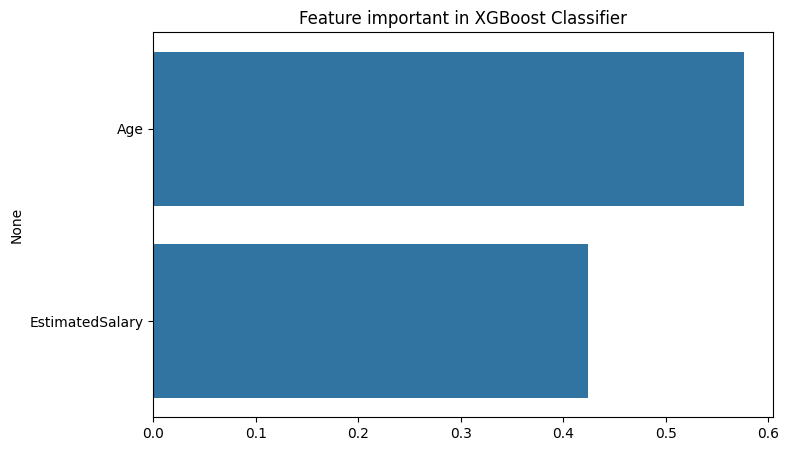

In [1078]:
#### extract all the important features from the dataset

features = xgb.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in XGBoost Classifier")
plt.show()

#### OBSERVATIONS:

1. The above graph depicts about the list of all the features of the Social Networks Ads along with their importances.

2. Age is the feature in Social Networks Ads dataset that is having the highest feature importance. So "age" should be given the highest importance.

3. EstimatedSalary is the feature in Social Networks Ads dataset that is having the lowest feature importance. So "EstimatedSalary" should be given the least importance.

#### Step 12:   Perform Hyper Parameter Tuning using GridSearchCV

In [1079]:
#### define the pipeline

from  sklearn.pipeline      import      Pipeline

#### craete the object for pipeline

pipeline    =   Pipeline([
    ("sc"       ,       StandardScaler())           ,
    ("xgb"      ,       XGBClassifier())
])

In [1080]:
#### define the paramgrid

param_grid = {
    "xgb__n_estimators"     :   [50,100,200]        ,
    "xgb__learning_rate"    :   [0.01,0.1,0.2]      ,
    "xgb__max_depth"        :   [3,5,7]             ,
    "xgb__subsample"        :   [0.8,1.0]
}

#### OBSERVATIONS:

n_estimators ==================>  No of decision trees used

learning_rate ==================>  It depicts how much each decision tree contribute

max_depth   ====================>  Maximum depth of each decision tree

subsample ======================>  Percentage of the training data used for  each decision tree

In [1081]:
#### perform the cross validation

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [1082]:
#### create the object of GridSearchCV

grid = GridSearchCV(
    pipeline                    ,
    param_grid  =   param_grid  ,
    cv          =    cv         ,
    scoring     =   'accuracy'  ,
    n_jobs      =    -1
)

In [1083]:
#### Train the Grid Search CV Model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric=None,
                                                      feature_types=...
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.01, 0.1, 0.2],
                         'xgb__max_depth': [3, 5, 7],
                         'xgb__n_estimators': [50, 100, 200],
                         'xgb__subsample': [0.8, 1.0]},
             scoring='accuracy')

In [1084]:
#### Obtain the best parameters and estimators of the model

best_parameters = grid.best_params_

print("Best Parameters of the model is:", best_parameters)


best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,


In [1085]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [1086]:
Y_pred_grid

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0])

In [1087]:
#### Evaluate the Classification Metrics

from   sklearn.metrics   import  accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)


print("===============================Precision Score=======================================================")

prgrid = precision_score(Y_test, Y_pred_grid)

print("Precision score of the model is:", prgrid)


print("===============================Recall Score=======================================================")

regrid = recall_score(Y_test, Y_pred_grid)

print("Recall score of the model is:", regrid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 90.0
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[46  5]
 [ 3 26]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80

===============================Precision Score=======================================================
Precision score of the model is: 0.8387096774193549
===============================Recall Score===================================

#### OBSERVATIONS:

1.  The accuracy of the XG Boost Classifier using Social Networks Ads dataset has increased from 87.5 to 90 So the model is working fine.

2.  Hence the accuracy of the model has improved using Hyper Parameter Tuning using GridSearchCV

#### Step 13: Predict whether the customer has purchased the product or not based on the sample data using Hyper Parameter Tuning with GridSearchCV

In [1088]:
#### define the sample data

sample = X.iloc[[395]]

print(sample)

#### perform the predictions based on the sample data

prediction = best_estimator.predict(sample)

print(prediction)

if(prediction[0] == 1):
    print("Customer has purchased the Social Netwoks Ads (1)")
else:
    print("Customer has not purchased the Social Netwoks Ads (0)")

     Age  EstimatedSalary
395   46            41000
[1]
Customer has purchased the Social Netwoks Ads (1)


#### Step 14: Visualizing the Feature Importances after performing Hyper Parameter Tuning

[0.4987892 0.5012108]
[1 0]
Index(['Age', 'EstimatedSalary'], dtype='object')


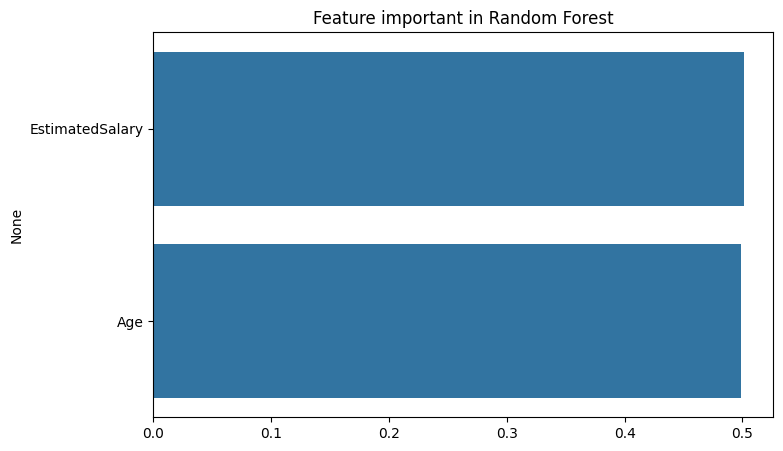

In [1089]:
#### extract all the important features from the dataset

xgb_model = best_estimator.named_steps["xgb"]

features = xgb_model.feature_importances_

print(features)


#### sort all the important features in the descending order of their indices

indices = np.argsort(features)[::-1]

print(indices)


#### extract all the columns from the dataset

res = X.columns

print(res)


#### Plot all the important features in the dataset
plt.figure(figsize=(8,5))
sns.barplot(x=features[indices], y=res[indices])
plt.title("Feature important in Random Forest")
plt.show()
